# LIME

LIME (Local Interpretable Model-agnostic Explanations) is a popular XAI framework designed to explain neural network decisions in a model-agnostic and instance-specific manner. It supports explanations across various data modalities, including images, text, and tabular data. This page summarizes the key components of LIME, its applications, and known issues.

![LIME Framework](images/lime_framework.png)
*Figure: LIME Framework*

Knab, Patrick & Marton, Sascha & Schlegel, Udo & Bartelt, Christian. (2025). Which LIME should I trust? Concepts, Challenges, and Solutions. 10.48550/arXiv.2503.24365. 

- <b>Feature Generation</b>: LIME builds a local, interpretable surrogate model by creating features based on the input modality (e.g., superpixels for images). Segmentation techniques reduce feature complexity.
- <b>Sample Generation</b>: Perturbed samples are generated by selectively modifying features of the input instance.
- <b>Feature Attribution</b>: A proximity measure assigns weights to perturbed samples, and a linear surrogate model approximates the original model’s behavior.
- <b>Explanation Representation</b>: Explanations are provided based on the coefficients of the surrogate model – highlighting key parts of images, text, or tabular data.

## Explain a tabular classifier through LORE

LORE provides interpretable explanations for the decisions made by machine learning models, particularly in situations where it might be challenging to explain the model's behavior using traditional methods. LORE is designed to offer explanations on a per-instance basis, meaning it provides insights into why a specific prediction was made for a particular data point. This is in contrast to global explanations that aim to provide an overview of a model's behavior across the entire dataset.


In this tutorial we will explain the reasoning of a random forest classifier when applied to an instance of the Adult Income dataset ( https://archive.ics.uci.edu/dataset/2/adult). This dataset contains census data from 1994 census database, the classification problem associated to such data involves the prediction of the annual income of a person, given a set of socio-economic caracteristics: 
- working class
- marital status
- occupation
- relationship
- race
- sex
- capital gain/loss
- native country 

In [1]:
# Import necessary libraries and modules from lore_sa and ucimlrepo
from ucimlrepo import fetch_ucirepo 
from lore_sa.dataset import TabularDataset
from lore_sa.lore import TabularRandomGeneratorLore
from lore_sa.bbox import sklearn_classifier_bbox
from lore_sa.encoder_decoder import ColumnTransformerEnc
from lore_sa.neighgen import RandomGenerator
from lore_sa.surrogate import DecisionTreeSurrogate

# Other packages needed for data manipulation and model building
import pandas as pd
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

### Dataset loading 

Lore libray has a module devoted to dataset handling. Here we use TabularDataset class to load a dataset from a csv file. A TabularDataset has a column that represent the target class (`class_name`) of the classification task  object, and has two main attributes: 
- `df` : a pandas dataframe representing the tabular data
- `descriptor` : a dictionary containing internal data related to the dataset. It is build when a TabularDataset is created, but it could also be edited. It is used by the next steps of LORE methodology to distinguish among numerical, categorical, ordinal and target features of the dataset.

In [2]:
dataset = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
row_names = ["Age", "Workclass", "Fnlwgt", "Education", "EducationNum", "MaritalStatus",
        "Occupation", "Relationship", "Race", "Gender", "CapitalGain", "CapitalLoss",
        "HoursPerWeek", "Country", "Income"]
us_adult_income = pd.read_csv(dataset, names=row_names,na_values=[' ?'])
# Convert to dataframe
df = us_adult_income.reset_index(drop=True)
dataset = TabularDataset(df, class_name="Income")
dataset.df.dropna(inplace=True)
dataset.df

,Age,Workclass,Fnlwgt,Education,EducationNum,MaritalStatus,Occupation,Relationship,Race,Gender,CapitalGain,CapitalLoss,HoursPerWeek,Country,Income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


The `TabularDataset` class does some data inspection and preparation when it is created starting from a text-based file. Each attribute of the data is analysed to derive type and internal statistics. The `descriptor` field is automatically updates with these information. In particular, the `descriptor` is a dictionary that contains the following keys:
- `numerical` : a dictionary containing the numerical features of the dataset and their statistics
- `categorical` : a dictionary containing the categorical features of the dataset and their statistics
- `ordinal` : (this is still not implemented) a dictionary containing the ordinal features of the dataset and their statistics
- `target` : the details of the target feature of the dataset and its statistics  

In [3]:
print(dataset.descriptor.keys())
dataset.df.drop(['Fnlwgt', 'EducationNum'], inplace=True, axis=1)
dataset.update_descriptor()

dict_keys(['numeric', 'categorical', 'ordinal', 'target'])


Before proceeding with the explanation, let's do some data preprocessing by dropping a few attributes that are not relevant for the learning. 

We operate directly on the `df` attribute of the dataset, then we update the descriptor.


### Model Learning

We start by training a Random Forest classifier on the Adult dataset. We will use the `df` attribute of the dataset, which is a pandas dataframe containing the tabular data. We will use the `class_name` attribute of the dataset to identify the target feature of the classification task. Since the data contains non-numeric attributes, we proceed with a preprocessing of the data to mange these attributes. We will exploit `Pipeline` class from `sklearn` to create a pipeline that applies one-hot encoding to the categorical features and label encoding to the target feature. 

In [4]:
# Model learning
def train_model(dataset: TabularDataset):
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), [0,8,9,10]),
            ('cat', OrdinalEncoder(), [1,2,3,4,5,6,7,11])
        ]
    )
    model = make_pipeline(preprocessor, RandomForestClassifier(n_estimators=100, random_state=42))
    
    X_train, X_test, y_train, y_test = train_test_split(dataset.df.loc[:, 'Age':'Country'].values, dataset.df['Income'].values,
                test_size=0.3, random_state=42, stratify=dataset.df['Income'].values)
    model.fit(X_train, y_train)
    
    return sklearn_classifier_bbox.sklearnBBox(model)

In [5]:
bbox = train_model(dataset)

### Explanation

Given the blackbox model, we can now explain the reasoning behind the classification of a specific instance. We will use the `LORE` class to explain the classification of the first instance of the dataset. The `explain_instance` method of the `LORE` class takes as input the instance to be explained, the blackbox model, and the dataset. It returns an explanation object that contains the explanation of the classification of the instance.

The constructor of the explanator class takes as input the blackbox model and the dataset. The `dataset` instance is used to get the information from the descriptor. In case the trainin set is not available, the descriptor could be built from the test set or by the metadata of the dataset.

In [6]:
tabularLore = TabularRandomGeneratorLore(bbox, dataset)

In [ ]:
num_row = 10
x = dataset.df.iloc[num_row][:-1] # we exclude the target feature
# when
explanation = tabularLore.explain(x)
# then
explanation

### Drill down the explanation process

The example above shows the explanation of the classification of one of the instances of the dataset. The `TabularRandomGenerator` encapsulates many of the deatils of the explanation process. The class construct and explanation pipeline that is composed by the following steps:
- **Neighborhood generation**: the neighborhood of the instance to be explained is generated. The neighborhood is a synthetic dataset that is created by generating random instances around the instance to be explained. The neighborhood is used to understand the behavior of the blackbox model in the vicinity of the instance to be explained.
- **Encoding**: the neighborhood dataset is encoded using one-hot encoding. The encoded neighborhood dataset is used to train the surrogate model.
- **Surrogate model**: a surrogate model is trained on the neighborhood dataset. The surrogate model is a simpler model that approximates the behavior of the blackbox model in the neighborhood of the instance to be explained. The surrogate model is used to extract classification rules that explain the behavior of the blackbox model.
- **Rule extraction**: the classification rules are extracted from the surrogate model. The classification rules are used to explain the classification of the instance to be explained. The classification rules provide insights into the features that are important for the classification of the instance.

Each of these step can be customized separately, in order to adapt the explanation process to the specific needs of the user. For example, let's construct an explanation process by managing manually the choice of each component of the explanation pipeline.

#### Encoding / Decoding

We use a `ColumnTransformerEnc` to exploit the `TransformerMixin` interface of the `sklearn` transformers. The `ColumnTransformerEnc` class is a wrapper around the `ColumnTransformer` class that provides the `encode` and `decode` methods to encode and decode the dataset. The `encode` method applies the transformations of the transformers to the dataset, while the `decode` method applies the inverse transformations to the dataset. The `ColumnTransformerEnc` class is used to encode and decode the dataset in the explanation process. 

In [10]:
tabular_enc = ColumnTransformerEnc(dataset.descriptor)
ref_value = dataset.df.iloc[0].values[:-1]
encoded = tabular_enc.encode([ref_value])
decoded = tabular_enc.decode(encoded)

print(f"Original value: {ref_value}")
print(f"Encoded value: {encoded}")
print(f"Decoded value: {decoded}")

Original value: [39 ' State-gov' ' Bachelors' ' Never-married' ' Adm-clerical'
 ' Not-in-family' ' White' ' Male' 2174 0 40 ' United-States']
Encoded value: [[39 2174 0 40 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
  0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]]
Decoded value: [[39 ' State-gov' ' Bachelors' ' Never-married' ' Adm-clerical'
  ' Not-in-family' ' White' ' Male' 2174 0 40 ' United-States']]


#### Neighborhood generation
Now that we are able to encode and decode the dataset, we can generate the neighborhood of the instance to be explained. To personalize the neighborhood generation process, we create now a Genetic Generator, using the class `GeneticGenerator`. The neighborhood is a synthetic dataset that is created by generating random instances around the instance to be explained, refined with a genetic algorithm to obtain a more dense and compact neighborhood.

In [ ]:
num_row = 10
x = dataset.df.iloc[num_row][:-1]
z = tabular_enc.encode([x.values])[0] # remove the class feature from the input instance

gen = RandomGenerator(bbox=bbox, dataset=dataset, encoder=tabular_enc, ocr=0.1)
neighbour = gen.generate(z, 100, dataset.descriptor, tabular_enc)

print('Neighborhood', neighbour)

### surrogate model

The `surrogate` submodule creates a classifier and provides the methods to extract its corresponding classification rules. Once trained the surrogate, we extract a set of rules that explains why the surrogate model classifies the instance in a certain way. 

In the following example, the instance `x` has been classified as an adult with income less than 50k. The surrogate model has used the features `capital-gain`, `capital-loss`, `marital-status`, and `native-country`. 

In [12]:
# decode the neighborhood to be labeled by the blackbox model
neighb_train_X = tabular_enc.decode(neighbour)
neighb_train_y = bbox.predict(neighb_train_X)
# encode the target class to the surrogate model
neighb_train_yz = tabular_enc.encode_target_class(neighb_train_y.reshape(-1, 1)).squeeze()

dt = DecisionTreeSurrogate()
dt.train(neighbour, neighb_train_yz)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [13]:
num_row = 10
x = dataset.df.iloc[num_row][:-1] # remove the class feature from the input instance
z = tabular_enc.encode([x.values])[0]
rule = dt.get_rule(z, tabular_enc)
print('rule', rule)
crules, deltas = dt.get_counterfactual_rules(z, neighbour, neighb_train_yz, tabular_enc)
print('\n crules')
for c in crules:
    print(c)

rule premises:
CapitalGain <= 12437.081298828125
Education !=  Masters
Relationship !=  Unmarried 
consequence: Income =  <=50K

 crules
premises:
CapitalGain <= 12437.081298828125
Education =  Masters
Age <= 56.041900634765625 
consequence: Income =  >50K




#### Explanation (LORE)

The Random Forest classifier predicts that the selected individual has an **annual income ≤ $50K**.

LORE explains this prediction by learning a **local surrogate decision tree** around the instance and extracting an interpretable rule.

#### Explanation Rule

> **If** `CapitalGain ≤ 6133.57`
> **Then** `Income ≤ 50K`

This shows that **capital gain** is the dominant factor influencing the model’s decision for this instance. Since the individual’s capital gain is below the threshold, the model predicts a lower income class.

#### Counterfactual Rule

> **If** `CapitalGain > 6133.57`
> **Then** `Income > 50K`

This counterfactual indicates that increasing capital gain beyond the threshold would be sufficient to flip the model’s prediction.

#### Summary

* The explanation is **local** and valid near the instance.
* A single feature (capital gain) drives the decision.
* LORE provides both **reasoning** and **actionable insight**.

#### Official lora_sa Reference: [Link](https://github.com/kdd-lab/LORE_sa/blob/main/LORE_Tutorial.ipynb)
---





### LORE Reflection & Concept Check

#### 1️. Why does LORE generate synthetic neighborhood samples instead of explaining the original dataset directly?

**Answer:**

LORE builds a *local surrogate decision tree* around a single instance.
To approximate the model’s decision boundary near that point, it must generate synthetic samples in the neighborhood.

This allows it to:

* Approximate local behavior even for black-box models
* Extract human-readable decision rules
* Produce counterfactual rules

Without synthetic sampling, LORE could not reliably approximate the local decision boundary.


#### 2. What is the difference between LORE’s explanation rule and a counterfactual rule?

**Answer:**

* **Explanation rule**: Conditions that justify the current prediction

  > “If PAY_0 > 2 and LIMIT_BAL < 50k → Default”

* **Counterfactual rule**: Minimal changes required to flip the prediction

  > “If PAY_0 ≤ 1 → No Default”

Explanation rules describe *why this happened*.
Counterfactual rules describe *what would need to change*.

Counterfactuals are especially useful for actionable insights.

### References:
Guidotti, R., Monreale, A., Ruggieri, S., Pedreschi, D., Turini, F., & Giannotti, F. (2018).
Local rule-based explanations of black box decision systems.
arXiv:1805.10820. https://arxiv.org/abs/1805.10820
-- -

## DSEG-LIME

***Abstract.*** Explainable Artificial Intelligence is critical in unraveling decision-making processes in complex machine learning models. LIME (Local Interpretable Model-agnostic Explanations) is a well-known XAI framework for image analysis. It utilizes image segmentation to create features to identify relevant areas for classification. Consequently, poor segmentation can compromise the consistency of the explanation and undermine the importance of the segments, affecting the overall interpretability. Addressing these challenges, we introduce **DSEG-LIME** (**D**ata-Driven **Seg**mentation **LIME**), featuring: ***i)*** a data-driven segmentation for human-recognized feature generation, and ***ii)*** a hierarchical segmentation procedure through composition. We benchmark DSEG-LIME on pre-trained models with images from the ImageNet dataset - scenarios without domain-specific knowledge. The analysis includes a quantitative evaluation using established XAI metrics, complemented by a qualitative assessment through a user study. Our findings demonstrate that DSEG outperforms in most of the XAI metrics and enhances the alignment of explanations with human-recognized concepts, significantly improving interpretability.


In [1]:
import sys
print(sys.executable)
print(sys.version)

/projects/aixpert/users/aravind/interpretability_agent_bootcamp/.venv312/bin/python
3.12.11 (main, Jun 12 2025, 12:40:51) [Clang 20.1.4 ]


In [ ]:
import os
from __future__ import print_function, division

# PyTorch and related imports
import torch
from torchvision import transforms
from torchvision.models import resnet101, ResNet101_Weights
from torchvision.models.feature_extraction import create_feature_extractor

# Image processing and visualization
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Segment Anything Model (SAM) imports
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

# TensorFlow/Keras utilities
from tensorflow.keras.applications.efficientnet import decode_predictions

# DSEG-LIME utility
from src.utils.dseg_lime import DSEG_Lime

In [3]:
# Set cache directory for models and datasets
CACHE_DIR = "/fs01/projects/aixpert/users/aravind/cache/"
os.environ["TORCH_HOME"] = CACHE_DIR
os.environ["HF_HOME"] = CACHE_DIR
os.environ["TRANSFORMERS_CACHE"] = CACHE_DIR
torch.hub.set_dir(CACHE_DIR)

### Models
In this project, we utilize the following pretrained models:

Models for segmentation:
- [Segment Anything (SAM)](https://arxiv.org/abs/2304.02643) - Here [GIT](https://github.com/facebookresearch/segment-anything?tab=readme-ov-file#model-checkpoints), you can download the model checkpoint and insert it into the [models/pretrained](models/pretrained/) folder.
- [End-to-End Object Detection with Transformers (DETR)](https://arxiv.org/abs/2005.12872) - Here [GIT](https://github.com/facebookresearch/detr), you can find the implementation. The models gets automatically installed by Python when executing the code.


Models for Explanation:
- [EfficientNet (B4)](https://arxiv.org/abs/1905.11946) - Here [GIT](https://github.com/facebookresearch/segment-anything?tab=readme-ov-file#model-checkpoints), you can download the model checkpoint and insert it into the [models](models) folder.
- [ResNet (101)](https://arxiv.org/abs/1512.03385) - Here [GIT](https://pytorch.org/hub/pytorch_vision_resnet/), you can find the implementation. The models gets automatically installed by Python when executing the code.
- [VisionTransformer (384)](https://arxiv.org/abs/2010.11929) - Here [GIT](https://huggingface.co/google/vit-large-patch32-384), you can find the implementation. The models gets automatically installed by Python when executing the code.


In [ ]:
# Load pre-trained ResNet101 model
model = resnet101(weights=ResNet101_Weights.DEFAULT)
model = torch.hub.load('pytorch/vision:v0.10.0', 'resnet101', pretrained=True)
cvmodel = model
cvmodel.eval()
# Create feature extractor to get features from 'avgpool' layer
feat_exp = create_feature_extractor(cvmodel, return_nodes=['avgpool'])
fc = model.fc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device).eval()
cvmodel = cvmodel.to(device).eval()
feat_exp = feat_exp.to(device).eval()

In [5]:
# Load Segment Anything Model (SAM)
sam_checkpoint = "./models/pretrained/sam_vit_h_4b8939.pth" # Adapt Path to SAM checkpoint
model_type = "vit_h"

# Initialize SAM model
sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
sam = sam.to(device)
sam.eval()
print(next(sam.parameters()).device)   # must be cuda
# sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
# mask_generator = SamAutomaticMaskGenerator(sam,
#                                            min_mask_region_area=512,
#                                             points_per_side=32,
#                                             )
# Initialize SAM Automatic Mask Generator
mask_generator = SamAutomaticMaskGenerator(
    sam,
    points_per_side=32, # 8 for quicker results
    min_mask_region_area=512 # 1024 for quicker results
)

/projects/aixpert/users/aravind/interpretability_agent_bootcamp/.venv312/lib/python3.12/site-packages/segment_anything/build_sam.py:105: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental f

cuda:0


In [6]:
# ImageNet data pre-processing pipelines
test_preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]) ### a complete imagenet data pre-process

image_reshape = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
]) ### process the imagenet data to sam

image_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
]) ### imagenet std and mean

# Define ImageModel class for predictions
class ImageModel:
    # Initialization method
    def __init__(self, model, image_norm, device="cuda"):
        self.model = model
        self.image_norm = image_norm
        self.device = device
        
    # Prediction method
    def predict (self, image_data):
        if image_data.ndim == 3:
            image_data = image_data[None, ...]

        # NumPy → Tensor (fast)
        batch = torch.stack(
            [self.image_norm(img) for img in image_data],
            dim=0
        ).to(self.device)

        with torch.no_grad():
            scores = self.model(batch)

        return scores

In [7]:
model = model.to(device).eval()

# Instantiate ImageModel
image_model = ImageModel(
    model=model,
    image_norm=image_norm,
    device=device
)
torch.set_grad_enabled(False)

In [8]:
# Define LIME explanation function
def lime_explanation_function(images):
    scores = image_model.predict(images)
    scores_np = scores.detach().cpu().numpy()
    return scores_np

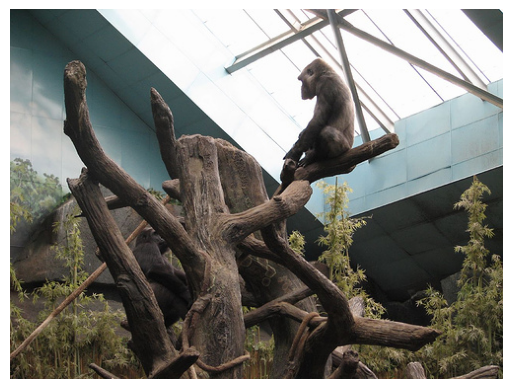

In [9]:
# Instantiate DSEG_Lime with the explanation function and mask generator
img_path = "./data/gorilla.JPEG"

img = Image.open(img_path).convert('RGB')
img_resized = image_reshape(img)              # ONCE
img_np = np.array(img_resized)                # ONCE

plt.imshow(img)
plt.axis(False)
plt.show()
plt.close()

# Create DSEG_Lime explainer
with torch.no_grad():
    predict_org = torch.nn.functional.softmax(
        model(test_preprocess(img).unsqueeze(0).to(device)),
        dim=1
    )
    predict_org.shape

In [10]:
# Instantiate DSEG_Lime
arg_position = 1

# Create DSEG_Lime explainer
pred_image_class = (
    torch.sort(predict_org, descending=True)
    .indices[0][arg_position]
    .item()
)

# Instantiate DSEG_Lime
label_class = decode_predictions(
    predict_org.detach().cpu().numpy().reshape(1, -1)
)

print(label_class)
print(pred_image_class)

[[('n02480855', 'gorilla', 0.8622275), ('n02486410', 'baboon', 0.0705218), ('n02488291', 'langur', 0.019666031), ('n02483362', 'gibbon', 0.01887201), ('n02487347', 'macaque', 0.011715909)]]
372


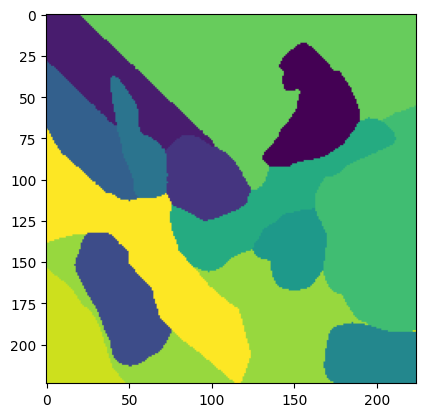

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:01<00:00, 190.17it/s]


In [11]:
# Instantiate DSEG_Lime  explainer
explainer = DSEG_Lime()

# Prepare image for explanation
img = Image.open(img_path).convert("RGB")
img_resized = image_reshape(img)      # Resize + CenterCrop ONCE
img_np = np.array(img_resized)

# Generate explanation
explanation = explainer.explain_instance(
    image=img_np,                     # single, consistent image
    classifier_fn=lime_explanation_function,
    feature_extractor=mask_generator,
    model=sam,
    image_path=img_path,
    iterations=1                      # important
)

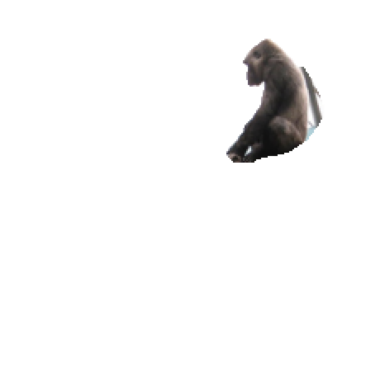

In [12]:
# Get image and mask from explanation
temp, mask = explanation.get_image_and_mask(explanation.top_labels[0], positive_only=True, num_features=1, hide_rest=True)
# Convert mask to 3D
mask_3d = np.stack([mask] * 3, axis=-1) # mask is (224, 224)
# Create a white background image
white_background = np.ones_like(img_np) * 255 # Use the SAME image that went into LIME
# Blend the original image with the white background using the mask
image_with_mask = np.where(mask_3d, img_np, white_background)
# Display the image with boundaries
plt.imshow(image_with_mask.astype(np.uint8))
plt.axis(False)
plt.show()

#### Explanation

The image is first passed through the pretrained image classification model to obtain the original prediction probabilities. The model predicts the class *gorilla* with high confidence, followed by semantically related classes such as *baboon*. This confirms that the classifier is operating in a meaningful region of the label space before explanation is applied.

To explain this prediction, DSEG-LIME is used as a local, model-agnostic explanation method. The explainer treats the classifier as a black box through the function `lime_explanation_function`, which maps perturbed images to prediction scores. Importantly, gradients are disabled during this process, ensuring that the explanation relies only on model outputs.

The image is segmented using the provided mask generator, producing semantically coherent regions rather than simple grid-based perturbations. DSEG-LIME then generates perturbed samples by selectively masking these regions and observing how the predicted probability for the target class changes. Using these perturbations, a sparse local surrogate model is fitted to approximate the classifier’s behavior in the neighborhood of the original image.

The resulting explanation mask highlights the region with the strongest positive contribution to the *gorilla* prediction. When visualized, only a small portion of the image—corresponding to the gorilla’s body—is retained, while the background is suppressed and replaced with a white canvas. This indicates that the classifier’s decision is primarily driven by the visual features of the animal itself rather than contextual background elements such as branches or enclosure structures.

Overall, the DSEG-LIME explanation demonstrates that the model’s prediction is based on semantically meaningful regions aligned with human intuition. By combining structured segmentation with LIME’s local surrogate modeling, DSEG-LIME provides a concise and interpretable explanation of why the image is classified as a gorilla.

#### Official Reference: [Link](https://github.com/patrick-knab/DSEG-LIME/tree/main)


---

### DSEG-LIME Reflection & Concept Check

#### 1️. How does DSEG-LIME differ from standard LIME?

**Answer:**

Standard LIME:

* Learns a local linear model
* Produces feature weights
* Sensitive to sampling randomness

DSEG-LIME:

* Segments feature space into structured regions
* Uses decision-tree-style partitioning
* Produces more stable, rule-based explanations

DSEG-LIME trades some flexibility for interpretability and stability.

#### 2️. Why might DSEG-LIME produce more stable explanations than LIME?

**Answer:**

Because:

* Decision-tree segmentation creates discrete partitions
* Rules are less sensitive to small perturbations
* Linear coefficients in LIME can fluctuate with sampling noise

However, tree segmentation can:

* Oversimplify nonlinear relationships
* Miss subtle interactions captured by linear local approximations


#### General question on LIME

**If two local explanation methods disagree, which one is “correct”?**

**Answer:**

Neither is inherently correct.
Local explanations approximate model behavior under different assumptions:

* LIME → Local linear approximation
* LORE → Local rule extraction
* DSEG-LIME → Structured local partition

They explain different *views* of the same model.

Agreement increases confidence.
Disagreement reveals model complexity or instability.

### References:
Knab, Patrick, Sascha Marton, and Christian Bartelt. "Beyond Pixels: Enhancing LIME with Hierarchical Features and Segmentation Foundation Models." arXiv preprint arXiv:2403.07733 (2024).